# Lab 2: Pandas for Cat and Dog Faces

In this notebook, you will treat the cat-and-dog-faces dataset as a **table** and practice core Pandas operations.

This lab is self-contained and does **not** depend on Lab 1. You will build the metadata table yourself from the folder structure, save it, load it with Pandas, and analyze it.

**Questions in this lab**

1. Build metadata from folders
2. Load the saved metadata with Pandas
3. Inspect the metadata table
4. Count each split by class
5. Audit metadata quality
6. Add analysis columns
7. Visualize split balance
8. Create a balanced sample by split and class


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from lab_utils.visualization import (
    plot_class_balance,
    plot_numeric_distribution,
)

# Safe project root (works in scripts + notebooks)
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

SEED = 1234
GENERATED_METADATA_PATH = ARTIFACT_DIR / f"lab2_faces_metadata.csv"
 
SPLITS = ("train", "val", "test")
LABELS = ("cat", "dog")
IMAGE_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
 
expected = [DATA_ROOT / split / label for split in SPLITS for label in LABELS]

print(f"Dataset root    : {DATA_ROOT}")
print(f"Metadata path   : {GENERATED_METADATA_PATH}")

Dataset root    : /workspaces/lab-2-pandas-elsongamer/data
Metadata path   : /workspaces/lab-2-pandas-elsongamer/artifacts/lab2_faces_metadata.csv


## Question 1: Build metadata from the folder structure

Break the metadata-building task into smaller helper functions, then call them from `build_metadata_from_folders(...)`.

Build a dataframe with at least these columns:

- `filepath`
- `label`
- `split`
- `width`
- `height`
- `mean_intensity`

### Suggested subtasks:

1. list image paths for one split and one label
2. inspect one image file to get width, height, and mean intensity
3. convert one image path into one metadata row
4. combine all rows into one dataframe

### Requirements

- `list_image_paths_for_group(data_root, split, label)` should return all image files for one `(split, label)` group.
- `inspect_image_file(path)` should:
  - open the image,
  - convert it to RGB,
  - return `(width, height, mean_intensity)`.
- `make_metadata_row(path, data_root, split, label)` should:
  - call `inspect_image_file(path)`,
  - return a dictionary with the required fields,
  - store `filepath` as a string relative to `data_root`.
- `build_metadata_from_folders(data_root)` should:
  - iterate through all splits and labels,
  - build one row per image,
  - return a sorted DataFrame.

### Notes

- `mean_intensity` should be computed from pixel values scaled to `[0, 1]`.
- Sort the final table by `split`, `label`, and `filepath`.

In [7]:
from pathlib import Path
import pandas as pd
from PIL import Image
import numpy as np
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png"]
DATA_ROOT = Path("data")
SPLITS = ["train", "val"]
LABELS = ["cat", "dog"]
GENERATED_METADATA_PATH = Path("metadata.csv")

def list_image_paths_for_group(data_root: Path, split: str, label: str) -> list[Path]:
    folder = data_root / split / label
    paths = []
    
    for ext in IMAGE_EXTENSIONS:
        paths.extend(folder.rglob(f"*{ext}"))
    
    return sorted(paths)
 
 
def inspect_image_file(path: Path) -> tuple[int, int, float]:
    with Image.open(path) as img:
        img = img.convert("RGB")
        width, height = img.size
        
        arr = np.array(img).astype("float32") / 255.0
        mean_intensity = arr.mean()
    
    return width, height, float(mean_intensity)
 
 
def make_metadata_row(path: Path, data_root: Path, split: str, label: str) -> dict[str, object]:
    width, height, mean_intensity = inspect_image_file(path)
    
    return {
        "filepath": str(path.relative_to(data_root)),
        "label": label,
        "split": split,
        "width": width,
        "height": height,
        "mean_intensity": mean_intensity,
    }
 
 
def build_metadata_from_folders(data_root: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label in LABELS:
            paths = list_image_paths_for_group(data_root, split, label)
            rows.extend(make_metadata_row(p, data_root, split, label) for p in paths)
    return (
        pd.DataFrame(rows)
        .sort_values(["split", "label", "filepath"])
        .reset_index(drop=True)
    )
 
 
folder_df = build_metadata_from_folders(DATA_ROOT)
print("metadata shape:", folder_df.shape)
display(folder_df.head())
 
folder_df.to_csv(GENERATED_METADATA_PATH, index=False)
print(f"Saved metadata to: {GENERATED_METADATA_PATH}")

metadata shape: (16, 6)


,filepath,label,split,width,height,mean_intensity
0,train/cat/cat_0001.jpg,cat,train,64,64,0.392492
1,train/cat/cat_0002.jpg,cat,train,64,64,0.431092
2,train/cat/cat_0003.jpg,cat,train,64,64,0.440590
3,train/cat/cat_0004.jpg,cat,train,64,64,0.442509
4,train/cat/cat_0005.jpg,cat,train,64,64,0.454387


Saved metadata to: metadata.csv


## Question 2: Load the saved metadata with Pandas

Use `pd.read_csv(...)` inside a small helper function.

This keeps the workflow realistic: build a table once, then reload it as a DataFrame for analysis.

### Requirements

- `load_metadata_table(csv_path)` should load the saved CSV file.
- The result should be a Pandas DataFrame.
- The loaded table must contain these columns:
  - `filepath`
  - `label`
  - `split`
  - `width`
  - `height`
  - `mean_intensity`


In [8]:
def load_metadata_table(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    
    # Optional safety check (recommended)
    required_cols = ["filepath", "label", "split", "width", "height", "mean_intensity"]
    missing = [col for col in required_cols if col not in df.columns]
    
    if missing:
        raise ValueError(f"Missing columns in CSV: {missing}")
    
    return df
 
df = load_metadata_table(GENERATED_METADATA_PATH)
print("loaded shape:", df.shape)
display(df.head())

loaded shape: (16, 6)


,filepath,label,split,width,height,mean_intensity
0,train/cat/cat_0001.jpg,cat,train,64,64,0.392492
1,train/cat/cat_0002.jpg,cat,train,64,64,0.431092
2,train/cat/cat_0003.jpg,cat,train,64,64,0.440590
3,train/cat/cat_0004.jpg,cat,train,64,64,0.442509
4,train/cat/cat_0005.jpg,cat,train,64,64,0.454387


## Question 3: Inspect the metadata table

Summarize the dataset with Pandas operations.

Return a dictionary with these keys:

- `rows` should be the number of rows in the DataFrame.
- `columns` should be the list of column names.
- `class_counts` should count the number of samples per label.
- `split_counts` should count the number of samples per split.

### Expected output format

```python
{
    "rows": int,                    # Total number of samples
    "columns": list[str],           # List of column names
    "class_counts": pd.Series,      # Frequency of each label (e.g., cat, dog)
    "split_counts": pd.Series       # Frequency of each split (train, val, test)
}


In [9]:
def summarize_metadata(frame: pd.DataFrame) -> dict[str, object]:
    class_counts = frame["label"].value_counts().sort_index()
    split_counts = frame["split"].value_counts().sort_index()
    
    return {
        "rows": len(frame),
        "columns": list(frame.columns),
        "class_counts": class_counts,
        "split_counts": split_counts,
    }
 
 
summary = summarize_metadata(df)
print("Rows    :", summary["rows"])
print("Columns :", summary["columns"])
print("\nClass counts:\n", summary["class_counts"])
print("\nSplit counts:\n", summary["split_counts"])
 
 
summary = summarize_metadata(df)
print("Rows    :", summary["rows"])
print("Columns :", summary["columns"])
print("\nClass counts:\n", summary["class_counts"])
print("\nSplit counts:\n", summary["split_counts"])

Rows    : 16
Columns : ['filepath', 'label', 'split', 'width', 'height', 'mean_intensity']

Class counts:
 label
cat    8
dog    8
Name: count, dtype: int64

Split counts:
 split
train    12
val       4
Name: count, dtype: int64
Rows    : 16
Columns : ['filepath', 'label', 'split', 'width', 'height', 'mean_intensity']

Class counts:
 label
cat    8
dog    8
Name: count, dtype: int64

Split counts:
 split
train    12
val       4
Name: count, dtype: int64


## Question 4: Count Samples per Split and Class

Create a table that summarizes how many images of each class appear in each dataset split.

This table should allow you to answer questions such as:
- How many dog images are in the training set?
- How many dog images are in the validation set?
- How many dog images are in the test set?
- And similarly for cats

### Requirements

Return a Pandas DataFrame where:
- Rows represent class labels (e.g., cat, dog)  
- Columns represent dataset splits (train, val, test)  
- Values represent the number of samples in each `(label, split)` combination

#### Example output

```text
split   test  train  val
label                    
cat        2      6    2
dog        2      6    2

In [10]:
def build_label_split_table(frame: pd.DataFrame) -> pd.DataFrame:
    table = (
        frame.groupby(["label", "split"])
        .size()
        .unstack(fill_value=0)
    )
    
    # Ensure ALL splits exist
    for split in ["train", "val", "test"]:
        if split not in table.columns:
            table[split] = 0
    
    return table[["train", "val", "test"]]
 
 
label_split_table = build_label_split_table(df)
display(label_split_table)

split,train,val,test
label,,,
cat,6,2,0
dog,6,2,0


## Question 5: Audit metadata quality

Check for the following data-quality issues:

- missing values  
- duplicated file paths  
- unexpected labels  
- non-positive image sizes  

### Requirements

Return a dictionary with these keys:

- `missing_values`  
- `duplicate_filepaths`  
- `bad_labels`  
- `non_positive_sizes`  

### Expected output format

- `missing_values`: a dictionary mapping each column name to its missing-value count  
- `duplicate_filepaths`: the number of duplicate file paths  
- `bad_labels`: a list of labels not in the allowed label set  
- `non_positive_sizes`: the number of rows where `width <= 0` or `height <= 0`  

#### Example

```python
{
    "missing_values": {
        "filepath": 0,
        "label": 0,
        "split": 0,
        "width": 0,
        "height": 0,
        "mean_intensity": 0,
    },
    "duplicate_filepaths": 0,
    "bad_labels": [],
    "non_positive_sizes": 0,
}
```

### Allowed labels

- `cat`  
- `dog`  

### Notes

- `bad_labels` should be empty for clean data.  
- `missing_values` should report counts per column.  
- `duplicate_filepaths` should count repeated file paths.  
- `non_positive_sizes` should count invalid image-size rows. 

In [11]:
def audit_metadata(frame: pd.DataFrame) -> dict[str, object]:
    allowed_labels = {"cat", "dog"}
    
    # 1. Missing values per column
    missing_values = frame.isna().sum().to_dict()
    
    # 2. Duplicate file paths
    duplicate_filepaths = frame["filepath"].duplicated().sum()
    
    # 3. Unexpected labels
    bad_labels = sorted(set(frame["label"]) - allowed_labels)
    
    # 4. Non-positive sizes
    non_positive_sizes = ((frame["width"] <= 0) | (frame["height"] <= 0)).sum()
    
    return {
        "missing_values": missing_values,
        "duplicate_filepaths": int(duplicate_filepaths),
        "bad_labels": bad_labels,
        "non_positive_sizes": int(non_positive_sizes),
    }
 
 
audit_report = audit_metadata(df)
print(audit_report)

{'missing_values': {'filepath': 0, 'label': 0, 'split': 0, 'width': 0, 'height': 0, 'mean_intensity': 0}, 'duplicate_filepaths': 0, 'bad_labels': [], 'non_positive_sizes': 0}


## Question 6: Add analysis columns

Create a helper function that returns a copy of the DataFrame with these new columns:

- `pixel_count = width * height`  
- `aspect_ratio = width / height`  
- `brightness_band`  
- `size_bucket`  

### Requirements

- Do not modify the input DataFrame in place.  
- Return a copy with the new columns added.  

### Column definitions

#### `pixel_count`

```python
pixel_count = width * height
```

#### `aspect_ratio`

```python
aspect_ratio = width / height
```

#### `brightness_band`

Use `pd.qcut(...)` on `mean_intensity` with 4 bins.

Use the following labels in order from darkest to brightest:

- `darkest`  
- `dim`  
- `bright`  
- `brightest`  

#### `size_bucket`

Create a size category based on `pixel_count` using a reference image size of **64 × 64 pixels**.

Define three categories:

- `small`: image is smaller than the reference size  
- `medium`: image is approximately equal to the reference size  
- `large`: image is larger than the reference size  

### Notes

- `brightness_band` should divide images into quartiles by brightness.  
- `size_bucket` should be a categorical size summary.  
- Keep the returned DataFrame aligned with the input rows.  

In [13]:
def add_analysis_columns(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()  # MUST keep original columns
    
    df["pixel_count"] = df["width"] * df["height"]
    df["aspect_ratio"] = df["width"] / df["height"]
    
    df["brightness_band"] = pd.qcut(
        df["mean_intensity"],
        q=4,
        labels=["darkest", "dim", "bright", "brightest"]
    )
    
    ref_size = 64 * 64
    
    def size_category(pixels):
        if pixels < ref_size:
            return "small"
        elif pixels == ref_size:
            return "medium"
        else:
            return "large"
    
    df["size_bucket"] = df["pixel_count"].apply(size_category)
    
    return df
 
 
analysis_df = add_analysis_columns(df)
display(analysis_df.head())

,filepath,label,split,width,height,mean_intensity,pixel_count,aspect_ratio,brightness_band,size_bucket
0,train/cat/cat_0001.jpg,cat,train,64,64,0.392492,4096,1.0,darkest,medium
1,train/cat/cat_0002.jpg,cat,train,64,64,0.431092,4096,1.0,dim,medium
2,train/cat/cat_0003.jpg,cat,train,64,64,0.440590,4096,1.0,bright,medium
3,train/cat/cat_0004.jpg,cat,train,64,64,0.442509,4096,1.0,bright,medium
4,train/cat/cat_0005.jpg,cat,train,64,64,0.454387,4096,1.0,bright,medium


## Question 7: Compare Image Characteristics Across Splits

Create a function that summarizes the average image characteristics for each dataset split (train, validation, and test).

Your output should be a table where:

- Each row corresponds to a dataset split  
- Each column contains a numeric summary such as average width, height, pixel count, or brightness  
- The table helps you compare how the splits differ in image size and intensity  

You should use Pandas `groupby()` operations to compute the summary statistics.

Output format
```python
split   avg_width  avg_height  avg_pixel_count  avg_mean_intensity
train        ...         ...              ...                 ...
val          ...         ...              ...                 ...
test         ...         ...              ...                 ...
```

In [14]:
def build_split_characteristics_table(frame: pd.DataFrame) -> pd.DataFrame:
    table = (
        frame.groupby("split")
        .agg({
            "width": "mean",
            "height": "mean",
            "pixel_count": "mean",
            "mean_intensity": "mean",
        })
        .rename(columns={
            "width": "avg_width",
            "height": "avg_height",
            "pixel_count": "avg_pixel_count",
            "mean_intensity": "avg_mean_intensity",
        })
        .sort_index()
    )
    
    return table
 
 
split_characteristics = build_split_characteristics_table(analysis_df)
display(split_characteristics)
 

,avg_width,avg_height,avg_pixel_count,avg_mean_intensity
split,,,,
train,64.0,64.0,4096.0,0.422217
val,64.0,64.0,4096.0,0.471832


## Question 8: Create a Balanced Sample by Split and Class

Create a function that generates a smaller dataset for fast experimentation.

The goal is to ensure the sampled dataset remains balanced across both:
- dataset splits (train, validation, test)
- class labels (cat and dog)

### Requirement

Sample up to `n` images from each `(split, label)` group.  
If a group contains fewer than `n` samples, take all available samples instead.

This ensures no group is oversampled and preserves natural dataset constraints.

### Properties to preserve

- Every split should still contain both classes (cat and dog when available)
- Each `(split, label)` group should contribute at most `n` samples
- The final dataset should remain balanced at the group level

### Expected Output Format

The function should return a **Pandas DataFrame** with the same structure as the input, but containing only the sampled rows.

sampled shape: (14, 10)


,filepath,label,split,width,height,mean_intensity,pixel_count,aspect_ratio,brightness_band,size_bucket
0,train/cat/cat_0001.jpg,cat,train,64,64,0.392492,4096,1.0,darkest,medium
1,train/cat/cat_0002.jpg,cat,train,64,64,0.431092,4096,1.0,dim,medium
2,train/cat/cat_0006.jpg,cat,train,64,64,0.463618,4096,1.0,brightest,medium
3,train/cat/cat_0003.jpg,cat,train,64,64,0.440590,4096,1.0,bright,medium
4,train/cat/cat_0005.jpg,cat,train,64,64,0.454387,4096,1.0,bright,medium


label,cat,dog
split,,
train,5,5
val,2,2


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Balanced sampled subset by split'}, xlabel='split', ylabel='Images'>)

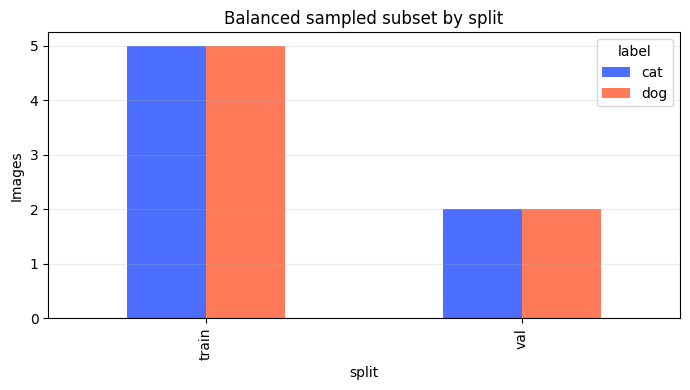

In [15]:
SEED = 42

def sample_balanced_by_split_and_label(frame, n_per_group, seed):
    samples = []
    
    for (split, label), group in frame.groupby(["split", "label"]):
        sampled = group.sample(
            n=min(len(group), n_per_group),
            random_state=seed
        )
        samples.append(sampled)
    
    return pd.concat(samples, ignore_index=True)
 
 
sample_size_per_group = 5
sampled_df = sample_balanced_by_split_and_label(
    analysis_df, n_per_group=sample_size_per_group, seed=SEED
)
print("sampled shape:", sampled_df.shape)
display(sampled_df.head())
 
sampled_balance = sampled_df.groupby(["split", "label"]).size().unstack(fill_value=0)
display(sampled_balance)
 
plot_class_balance(sampled_df, title="Balanced sampled subset by split")

## Reflection

Try writing short answers to these questions. These are meant for self-study only and will not be graded:

1. What are some other commonly used train-validation-test splits in practice?
2. What should we do when the dataset is small, like in this lab? Should we still follow the standard train-validation-test split?
3. Why is grouped sampling useful before training a model?
4. Which Pandas operation felt most useful in this lab: `groupby`, `value_counts`, `qcut`, or sampling within groups? Why?
